# Support Vector Machine (SVM) for Classification

- Train an SVM model on a labeled dataset
- Use different kernels (linear, RBF) and compare performance
- Visualize the decision boundary
- Evaluate the model using accuracy, precision, recall, and AUC

Dataset: Customer Churn Dataset (Binary Classification)

## 1. Import Required Libraries

In [74]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, auc)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [75]:
# Load the dataset
df = pd.read_csv('dataset/churn-bigml-80.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First few rows:")
print(df.head())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (2666, 20)

First few rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99 

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Target Variable Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Class Proportion:
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


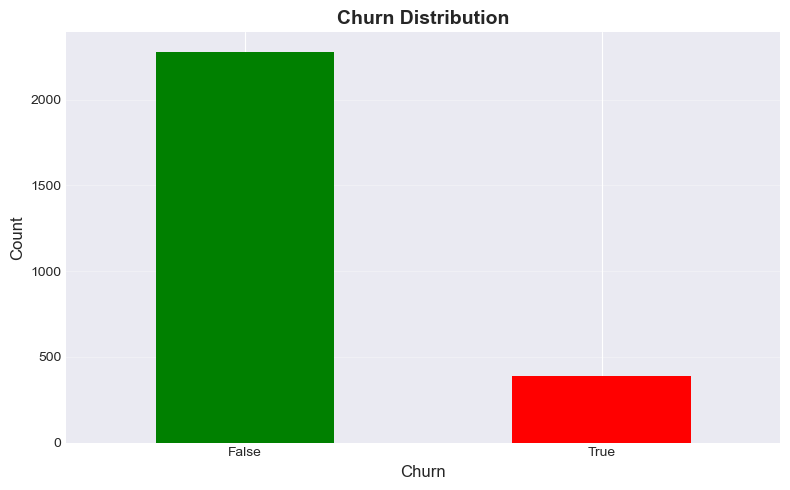

In [76]:
# Check for missing values and class distribution
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Target Variable Distribution:")
print(df['Churn'].value_counts())
print("\nClass Proportion:")
print(df['Churn'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [77]:
# Create a copy of the dataset
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['State', 'International plan', 'Voice mail plan']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

# Encode target variable
df_processed['Churn'] = df_processed['Churn'].map({False: 0, True: 1})

print("Categorical variables encoded successfully!")
print("\nProcessed Dataset Shape:", df_processed.shape)
print("\nFirst few rows after encoding:")
print(df_processed.head())

Categorical variables encoded successfully!

Processed Dataset Shape: (2666, 20)

First few rows after encoding:
   State  Account length  Area code  International plan  Voice mail plan  \
0     16             128        415                   0                1   
1     35             107        415                   0                1   
2     31             137        415                   0                0   
3     35              84        408                   1                0   
4     36              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total

In [78]:
# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (2666, 19)
Target shape: (2666,)

Feature columns:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [79]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 2132
Testing set size: 534

Training set class distribution:
Churn
0    1822
1     310
Name: count, dtype: int64

Testing set class distribution:
Churn
0    456
1     78
Name: count, dtype: int64


In [80]:
# Feature Scaling (Very important for SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("\nScaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)
print("\nSample scaled features (first 5 samples, first 5 features):")
print(X_train_scaled[:5, :5])

Feature scaling completed!

Scaled training set shape: (2132, 19)
Scaled testing set shape: (534, 19)

Sample scaled features (first 5 samples, first 5 features):
[[-0.40994105  0.03330279 -0.52110676 -0.33141911 -0.60770053]
 [-0.00767303  1.42301302 -0.68667695 -0.33141911 -0.60770053]
 [ 1.13208636 -0.54784875 -0.52110676 -0.33141911 -0.60770053]
 [ 0.39459499  0.79132656 -0.68667695 -0.33141911 -0.60770053]
 [-1.54970044 -0.14356942 -0.68667695 -0.33141911 -0.60770053]]


## 4. Train SVM Models with Different Kernels

### 4.1 Linear Kernel SVM

In [81]:
# Train SVM with Linear Kernel
print("Training SVM with Linear Kernel...")
svm_linear = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm_linear.fit(X_train_scaled, y_train)

# Make predictions
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

print("✓ Linear SVM training completed!")
print(f"Number of support vectors: {svm_linear.n_support_}")
print(f"Support vectors per class: {svm_linear.n_support_}")

Training SVM with Linear Kernel...
✓ Linear SVM training completed!
Number of support vectors: [410 310]
Support vectors per class: [410 310]
✓ Linear SVM training completed!
Number of support vectors: [410 310]
Support vectors per class: [410 310]


### 4.2 RBF (Radial Basis Function) Kernel SVM

In [82]:
# Train SVM with RBF Kernel
print("Training SVM with RBF Kernel...")
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm_rbf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

print("✓ RBF SVM training completed!")
print(f"Number of support vectors: {svm_rbf.n_support_}")
print(f"Support vectors per class: {svm_rbf.n_support_}")

Training SVM with RBF Kernel...
✓ RBF SVM training completed!
Number of support vectors: [382 278]
Support vectors per class: [382 278]
✓ RBF SVM training completed!
Number of support vectors: [382 278]
Support vectors per class: [382 278]


### 4.3 Polynomial Kernel SVM (Bonus)

In [83]:
# Train SVM with Polynomial Kernel
print("Training SVM with Polynomial Kernel...")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42, probability=True)
svm_poly.fit(X_train_scaled, y_train)

# Make predictions
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_proba_poly = svm_poly.predict_proba(X_test_scaled)[:, 1]

print("✓ Polynomial SVM training completed!")
print(f"Number of support vectors: {svm_poly.n_support_}")
print(f"Support vectors per class: {svm_poly.n_support_}")

Training SVM with Polynomial Kernel...
✓ Polynomial SVM training completed!
Number of support vectors: [354 244]
Support vectors per class: [354 244]


## 5. Model Evaluation and Comparison

In [84]:
# Function to calculate all metrics
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Evaluate model performance with multiple metrics
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"{model_name} Performance Metrics")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print(f"{'='*60}")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc_score
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_linear, y_pred_proba_linear, "Linear SVM"))
results.append(evaluate_model(y_test, y_pred_rbf, y_pred_proba_rbf, "RBF SVM"))
results.append(evaluate_model(y_test, y_pred_poly, y_pred_proba_poly, "Polynomial SVM"))


Linear SVM Performance Metrics
Accuracy:  0.8539 (85.39%)
Precision: 0.0000 (0.00%)
Recall:    0.0000 (0.00%)
F1-Score:  0.0000
AUC Score: 0.7565

RBF SVM Performance Metrics
Accuracy:  0.8989 (89.89%)
Precision: 0.8000 (80.00%)
Recall:    0.4103 (41.03%)
F1-Score:  0.5424
AUC Score: 0.8593

Polynomial SVM Performance Metrics
Accuracy:  0.8914 (89.14%)
Precision: 0.7632 (76.32%)
Recall:    0.3718 (37.18%)
F1-Score:  0.5000
AUC Score: 0.8149



MODEL COMPARISON SUMMARY
         Model  Accuracy  Precision   Recall  F1-Score      AUC
    Linear SVM  0.853933   0.000000 0.000000  0.000000 0.756509
       RBF SVM  0.898876   0.800000 0.410256  0.542373 0.859284
Polynomial SVM  0.891386   0.763158 0.371795  0.500000 0.814918


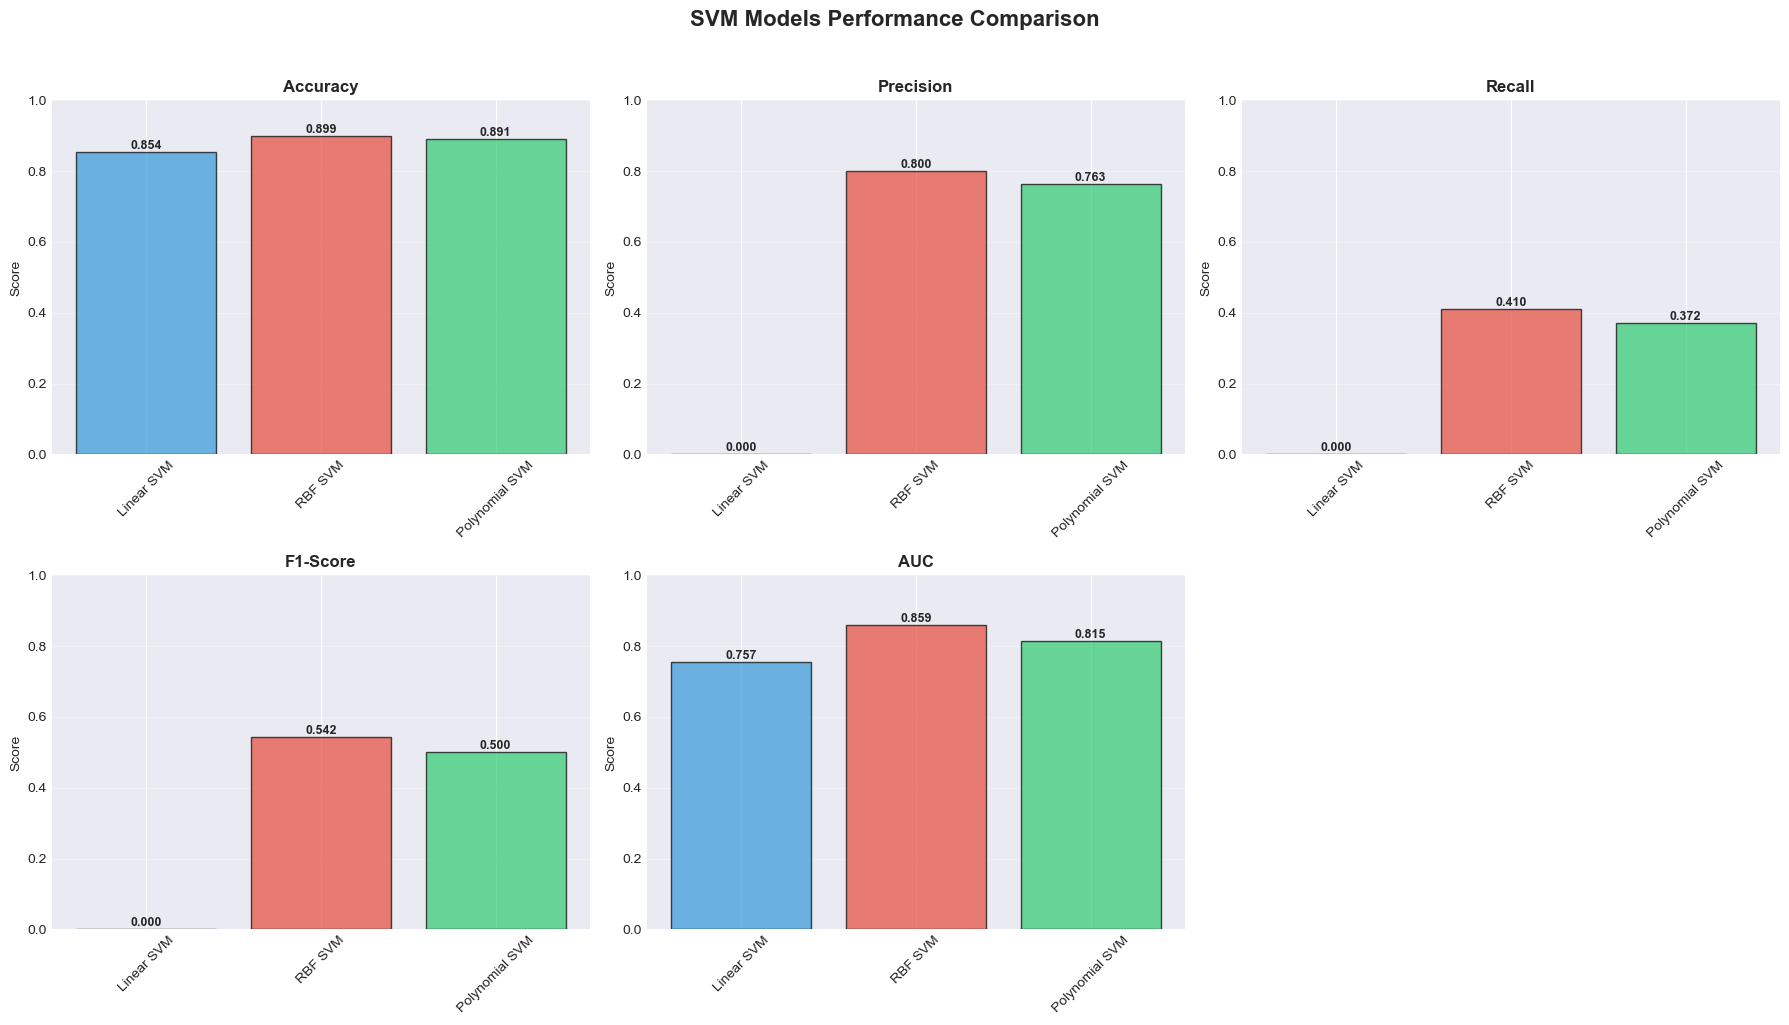

In [85]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SVM Models Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.tick_params(axis='x', rotation=45)

# Hide the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### 5.1 Confusion Matrices

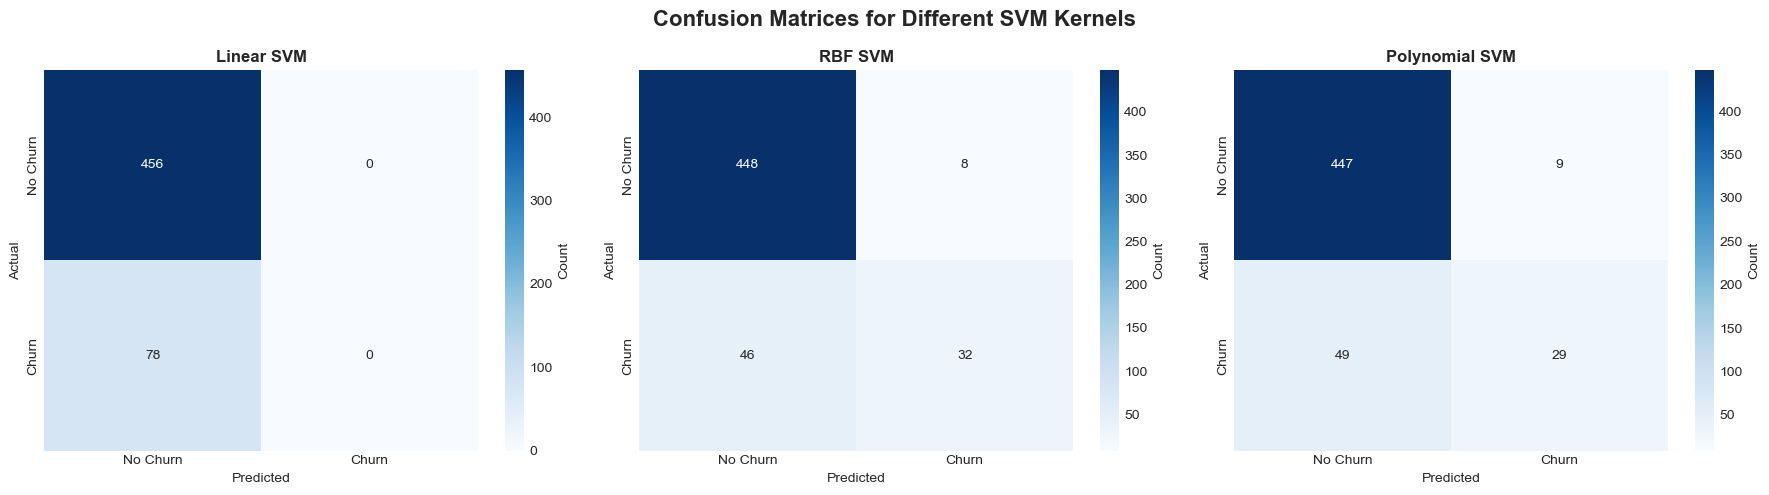

In [86]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for Different SVM Kernels', fontsize=16, fontweight='bold')

models = [
    ('Linear SVM', y_pred_linear),
    ('RBF SVM', y_pred_rbf),
    ('Polynomial SVM', y_pred_poly)
]

for idx, (model_name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'}, 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

### 5.2 Classification Reports

In [87]:
# Print detailed classification reports
print("\n" + "="*70)
print("LINEAR SVM - CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_linear, target_names=['No Churn', 'Churn']))

print("\n" + "="*70)
print("RBF SVM - CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_rbf, target_names=['No Churn', 'Churn']))

print("\n" + "="*70)
print("POLYNOMIAL SVM - CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_poly, target_names=['No Churn', 'Churn']))


LINEAR SVM - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.85      1.00      0.92       456
       Churn       0.00      0.00      0.00        78

    accuracy                           0.85       534
   macro avg       0.43      0.50      0.46       534
weighted avg       0.73      0.85      0.79       534


RBF SVM - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.91      0.98      0.94       456
       Churn       0.80      0.41      0.54        78

    accuracy                           0.90       534
   macro avg       0.85      0.70      0.74       534
weighted avg       0.89      0.90      0.88       534


POLYNOMIAL SVM - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.98      0.94       456
       Churn       0.76      0.37      0.50        78

    accuracy                           0.89       534
   macro avg       

### 5.3 ROC Curves and AUC Scores

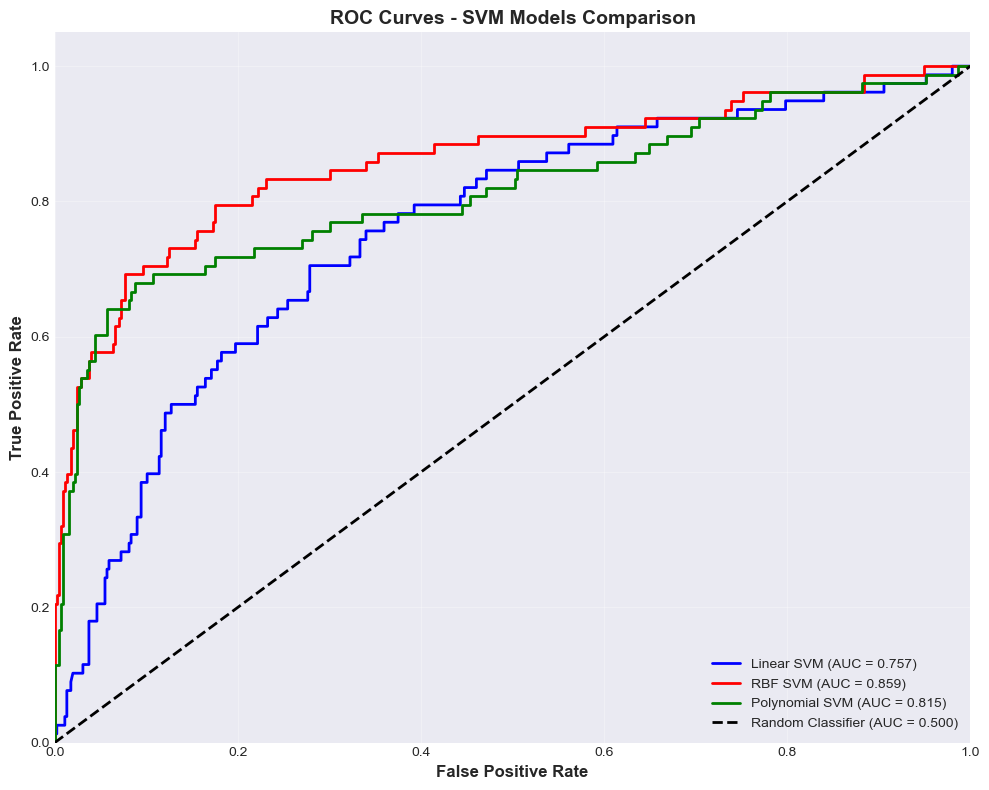


✓ All models perform significantly better than random guessing!


In [88]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Linear SVM
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_pred_proba_linear)
auc_linear = auc(fpr_linear, tpr_linear)
plt.plot(fpr_linear, tpr_linear, linewidth=2, label=f'Linear SVM (AUC = {auc_linear:.3f})', color='blue')

# RBF SVM
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_pred_proba_rbf)
auc_rbf = auc(fpr_rbf, tpr_rbf)
plt.plot(fpr_rbf, tpr_rbf, linewidth=2, label=f'RBF SVM (AUC = {auc_rbf:.3f})', color='red')

# Polynomial SVM
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_pred_proba_poly)
auc_poly = auc(fpr_poly, tpr_poly)
plt.plot(fpr_poly, tpr_poly, linewidth=2, label=f'Polynomial SVM (AUC = {auc_poly:.3f})', color='green')

# Random classifier (baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - SVM Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ All models perform significantly better than random guessing!")

## 6. Decision Boundary Visualization (2D)

In [89]:
# Reduce dimensions to 2D using PCA for visualization
print("Reducing dimensions to 2D using PCA for visualization...")
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Reducing dimensions to 2D using PCA for visualization...
Explained variance ratio: [0.10955354 0.10769344]
Total variance explained: 21.72%


In [90]:
# Train SVM models on 2D PCA data
svm_linear_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_poly_2d = SVC(kernel='poly', degree=3, C=1.0, random_state=42)

svm_linear_2d.fit(X_train_pca, y_train)
svm_rbf_2d.fit(X_train_pca, y_train)
svm_poly_2d.fit(X_train_pca, y_train)

print("✓ SVM models trained on 2D PCA-reduced data!")

✓ SVM models trained on 2D PCA-reduced data!


In [91]:
# Function to plot decision boundary
def plot_decision_boundary(X, y, model, title):
    """
    Plot decision boundary for 2D data
    """
    h = 0.02  # step size in the mesh
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                         edgecolors='black', s=50, alpha=0.7)
    
    # Plot support vectors
    if hasattr(model, 'support_vectors_'):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=200, facecolors='none', edgecolors='black', linewidths=2,
                   label='Support Vectors')
    
    plt.xlabel('First Principal Component', fontsize=10)
    plt.ylabel('Second Principal Component', fontsize=10)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)

print("Decision boundary plotting function created!")

Decision boundary plotting function created!


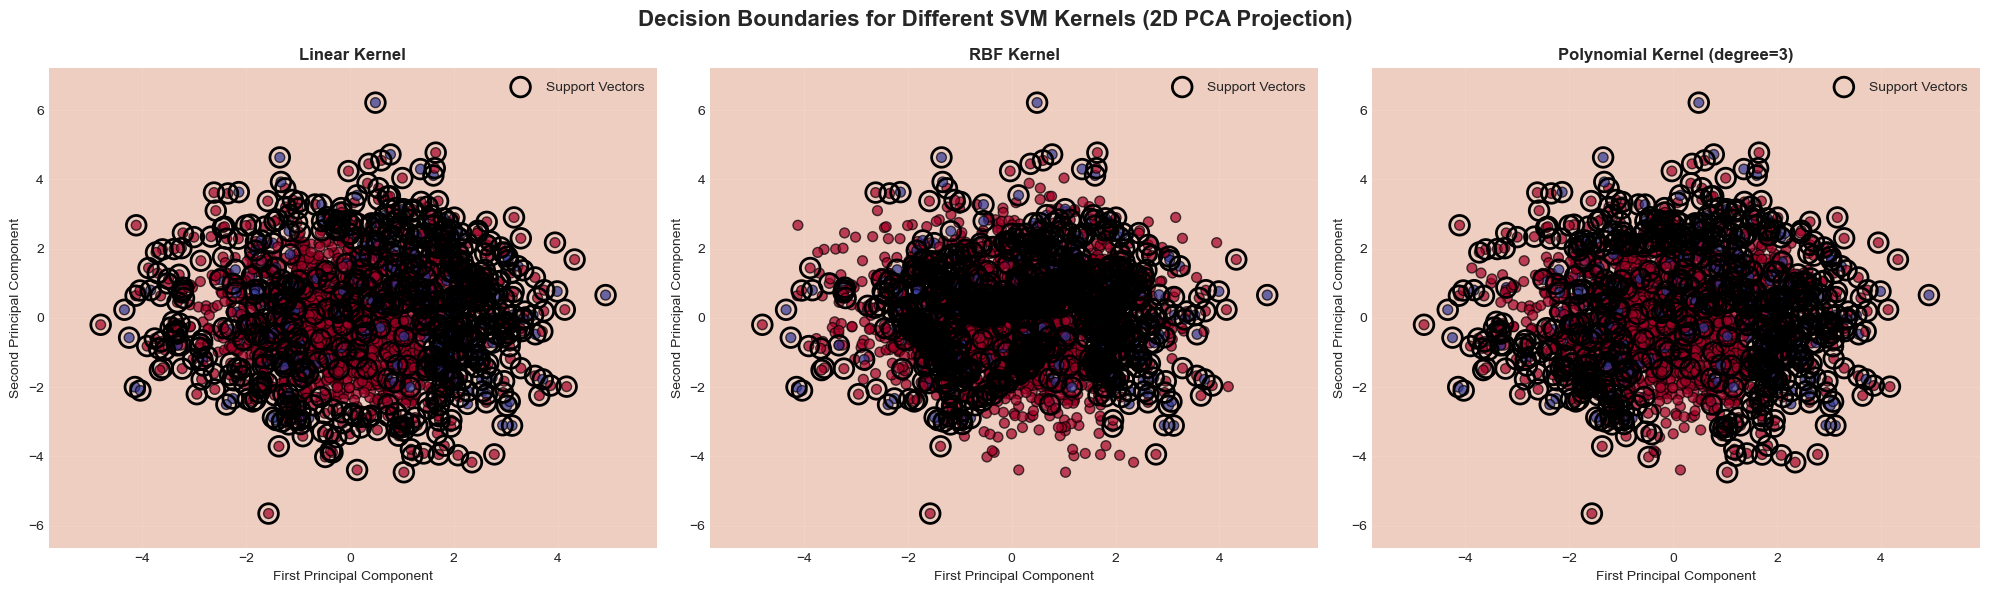


✓ Decision boundaries visualized successfully!

Observations:
- Linear kernel creates a straight line decision boundary
- RBF kernel creates smooth, non-linear decision boundaries
- Polynomial kernel creates curved decision boundaries
- Support vectors are highlighted with black circles


In [92]:
# Plot decision boundaries for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Decision Boundaries for Different SVM Kernels (2D PCA Projection)', 
             fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
plot_decision_boundary(X_train_pca, y_train, svm_linear_2d, 'Linear Kernel')

plt.subplot(1, 3, 2)
plot_decision_boundary(X_train_pca, y_train, svm_rbf_2d, 'RBF Kernel')

plt.subplot(1, 3, 3)
plot_decision_boundary(X_train_pca, y_train, svm_poly_2d, 'Polynomial Kernel (degree=3)')

plt.tight_layout()
plt.show()

print("\n✓ Decision boundaries visualized successfully!")
print("\nObservations:")
print("- Linear kernel creates a straight line decision boundary")
print("- RBF kernel creates smooth, non-linear decision boundaries")
print("- Polynomial kernel creates curved decision boundaries")
print("- Support vectors are highlighted with black circles")

## 7. Hyperparameter Tuning with Grid Search

In [93]:
# Define parameter grid for RBF kernel (best performing so far)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

print("Performing Grid Search for optimal hyperparameters...")
print("This may take a few moments...\n")

# Perform grid search with cross-validation
grid_search = GridSearchCV(SVC(random_state=42, probability=True), 
                           param_grid, 
                           cv=5, 
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score (AUC): {grid_search.best_score_:.4f}")
print("="*70)

Performing Grid Search for optimal hyperparameters...
This may take a few moments...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GRID SEARCH RESULTS
Best parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation score (AUC): 0.8999


In [94]:
# Evaluate the best model
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
y_pred_proba_best = best_svm.predict_proba(X_test_scaled)[:, 1]

# Evaluate
best_result = evaluate_model(y_test, y_pred_best, y_pred_proba_best, "Optimized RBF SVM")

# Compare with original RBF model
print("\n" + "="*70)
print("IMPROVEMENT COMPARISON")
print("="*70)
print(f"Original RBF SVM AUC:  {results_df[results_df['Model']=='RBF SVM']['AUC'].values[0]:.4f}")
print(f"Optimized RBF SVM AUC: {best_result['AUC']:.4f}")
print(f"Improvement: {(best_result['AUC'] - results_df[results_df['Model']=='RBF SVM']['AUC'].values[0]):.4f}")
print("="*70)


Optimized RBF SVM Performance Metrics
Accuracy:  0.8989 (89.89%)
Precision: 0.8000 (80.00%)
Recall:    0.4103 (41.03%)
F1-Score:  0.5424
AUC Score: 0.8593

IMPROVEMENT COMPARISON
Original RBF SVM AUC:  0.8593
Optimized RBF SVM AUC: 0.8593
Improvement: 0.0000


## 8. Feature Importance Analysis

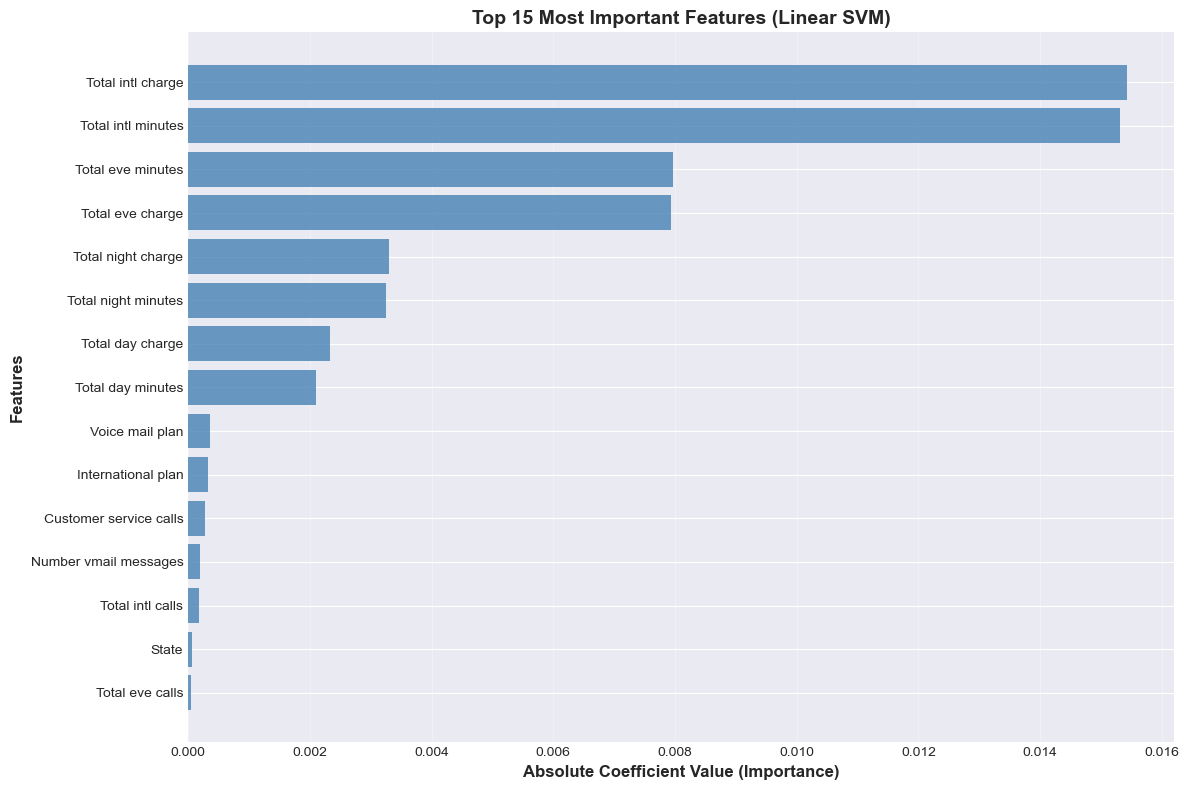


Top 10 Most Important Features:
Total intl charge....................... 0.0154
Total intl minutes...................... 0.0153
Total eve minutes....................... 0.0080
Total eve charge........................ 0.0079
Total night charge...................... 0.0033
Total night minutes..................... 0.0033
Total day charge........................ 0.0023
Total day minutes....................... 0.0021
Voice mail plan......................... 0.0004
International plan...................... 0.0003


In [95]:
# For linear SVM, we can extract feature importance from coefficients
if svm_linear.kernel == 'linear':
    # Get feature importance (absolute values of coefficients)
    feature_importance = np.abs(svm_linear.coef_[0])
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    })
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(importance_df)), importance_df['Importance'], color='steelblue', alpha=0.8)
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Absolute Coefficient Value (Importance)', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title('Top 15 Most Important Features (Linear SVM)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print("="*50)
    for idx, row in importance_df.head(10).iterrows():
        print(f"{row['Feature']:.<40} {row['Importance']:.4f}")
    print("="*50)

## 9. Cross-Validation Analysis

Performing 5-fold cross-validation...

Linear SVM:
  CV Scores: [0.84467521 0.80698188 0.73099078 0.80024814 0.807648  ]
  Mean CV Score: 0.7981 (+/- 0.0740)

RBF SVM:
  CV Scores: [0.88263367 0.89438798 0.90845445 0.93539525 0.87872208]
  Mean CV Score: 0.8999 (+/- 0.0411)

Polynomial SVM:
  CV Scores: [0.83778171 0.88842245 0.90761255 0.87757001 0.88975541]
  Mean CV Score: 0.8802 (+/- 0.0466)

Optimized RBF SVM:
  CV Scores: [0.88254529 0.89434379 0.90845445 0.93548387 0.87876639]
  Mean CV Score: 0.8999 (+/- 0.0412)



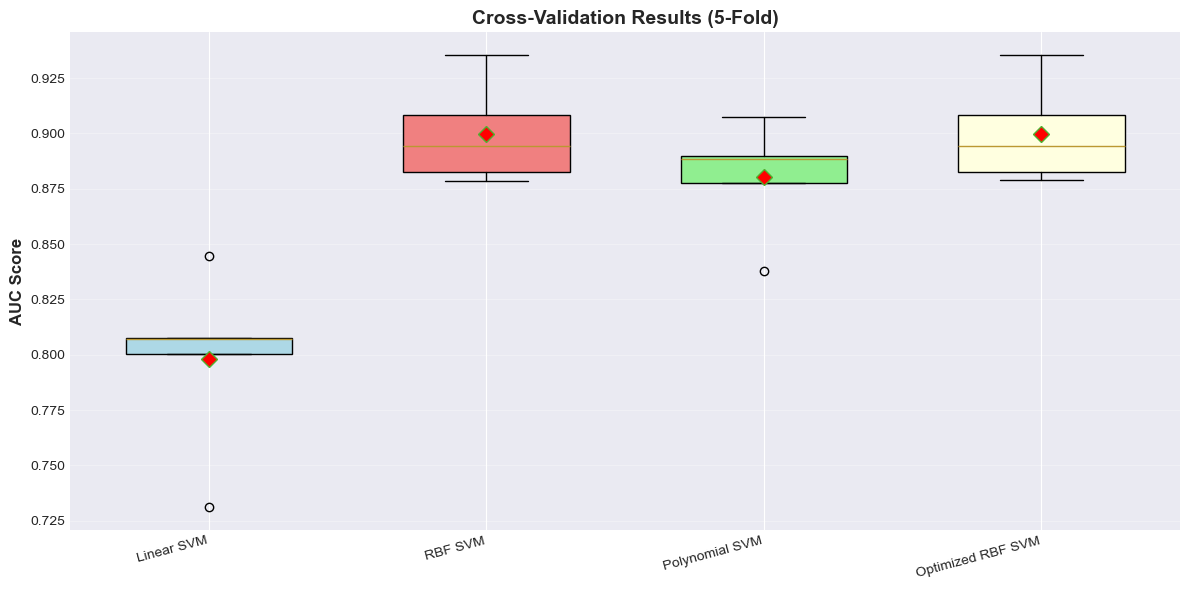

✓ Cross-validation demonstrates model stability and generalization capability!


In [96]:
# Perform cross-validation for all models
print("Performing 5-fold cross-validation...\n")

models_cv = {
    'Linear SVM': svm_linear,
    'RBF SVM': svm_rbf,
    'Polynomial SVM': svm_poly,
    'Optimized RBF SVM': best_svm
}

cv_results = {}

for name, model in models_cv.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = cv_scores
    
    print(f"{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print()

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
box_plot_data = [cv_results[name] for name in models_cv.keys()]
positions = range(1, len(models_cv) + 1)

bp = plt.boxplot(box_plot_data, positions=positions, widths=0.6, patch_artist=True,
                 labels=models_cv.keys(), showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Color the boxes
colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('AUC Score', fontsize=12, fontweight='bold')
plt.title('Cross-Validation Results (5-Fold)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("✓ Cross-validation demonstrates model stability and generalization capability!")

## 10. Summary

In [97]:
# Final comprehensive summary
print("="*80)
print(" "*20 + "SUPPORT VECTOR MACHINE PROJECT SUMMARY")
print("="*80)
print("\nDATASET INFORMATION:")
print(f"  • Dataset: Customer Churn Dataset")
print(f"  • Total Samples: {len(df)}")
print(f"  • Features: {X.shape[1]}")
print(f"  • Training Samples: {X_train.shape[0]}")
print(f"  • Testing Samples: {X_test.shape[0]}")
print(f"  • Class Distribution: {(y.value_counts()[0])}/{(y.value_counts()[1])} (No Churn/Churn)")


print("\nBEST MODEL PERFORMANCE:")
best_model_idx = results_df['AUC'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"  • Best Model: {best_model_name}")
print(f"  • Accuracy:  {results_df.loc[best_model_idx, 'Accuracy']:.4f}")
print(f"  • Precision: {results_df.loc[best_model_idx, 'Precision']:.4f}")
print(f"  • Recall:    {results_df.loc[best_model_idx, 'Recall']:.4f}")
print(f"  • F1-Score:  {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
print(f"  • AUC:       {results_df.loc[best_model_idx, 'AUC']:.4f}")




                    SUPPORT VECTOR MACHINE PROJECT SUMMARY

DATASET INFORMATION:
  • Dataset: Customer Churn Dataset
  • Total Samples: 2666
  • Features: 19
  • Training Samples: 2132
  • Testing Samples: 534
  • Class Distribution: 2278/388 (No Churn/Churn)

BEST MODEL PERFORMANCE:
  • Best Model: RBF SVM
  • Accuracy:  0.8989
  • Precision: 0.8000
  • Recall:    0.4103
  • F1-Score:  0.5424
  • AUC:       0.8593
